In [ ]:
using GeneralizedSasakiNakamura

In [2]:
using Plots, LaTeXStrings, Printf

In [10]:
# Deterministic ISEM demo for updating the README animation.
# The old Interact/WebIO version is avoided because that dependency stack is not reliable on current Julia/JSON versions.
function radial_demo_frame(; BC = IN, s = -2, l = 2, m = 2, a = 0.7, omega = 0.5)
    solve_time = @elapsed begin
        R = Teukolsky_radial(s, l, m, a, omega, BC)
        X = GSN_radial(s, l, m, a, omega, BC)
    end

    rsgrid = collect(-20:max(omega / 10, 0.01):100)
    rgrid = (rs -> r_from_rstar(a, rs)).(rsgrid)

    eval_time = @elapsed begin
        Rvals = R.(rgrid)
        Xvals = X.(rsgrid)
        yR = [real.(Rvals) imag.(Rvals)]
        yX = [real.(Xvals) imag.(Xvals)]
    end

    p1 = plot(rgrid, yR;
        xlabel = L"r/M",
        ylabel = L"R(r)",
        title = "Teukolsky $BC solution, s = $s, a = $a, omega = $(round(omega; digits = 2))",
        label = ["real" "imag"],
        legend = :outerbottomright,
        legendcolumns = 2,
    )

    p2 = plot(rsgrid, yX;
        xlabel = L"r_{*}/M",
        ylabel = L"X(r_{*})",
        label = ["real" "imag"],
        legend = :outerbottomright,
        legendcolumns = 2,
    )

    p3 = plot(;
        border = :none,
        ticks = nothing,
        annotation = [
            (0.1, 1.0, (@sprintf("incidence amplitude:\n %.6e + %.6e i", real(R.incidence_amplitude), imag(R.incidence_amplitude)), 8)),
            (0.45, 1.0, (@sprintf("reflection amplitude:\n %.6e + %.6e i", real(R.reflection_amplitude), imag(R.reflection_amplitude)), 8)),
            (0.8, 1.0, (@sprintf("transmission amplitude:\n %.2e + %.2e i", real(R.transmission_amplitude), imag(R.transmission_amplitude)), 8)),
            (0.5, 0.5, (@sprintf("solve time: %.6f ms,        evaluation on %d grid points: %.6f ms", (500 * solve_time), length(rgrid), (500 * eval_time)), 8)),
        ],
    )

    plot(p1, p2, p3; layout = (3, 1), size = (900, 760))
end

radial_demo_frame (generic function with 1 method)

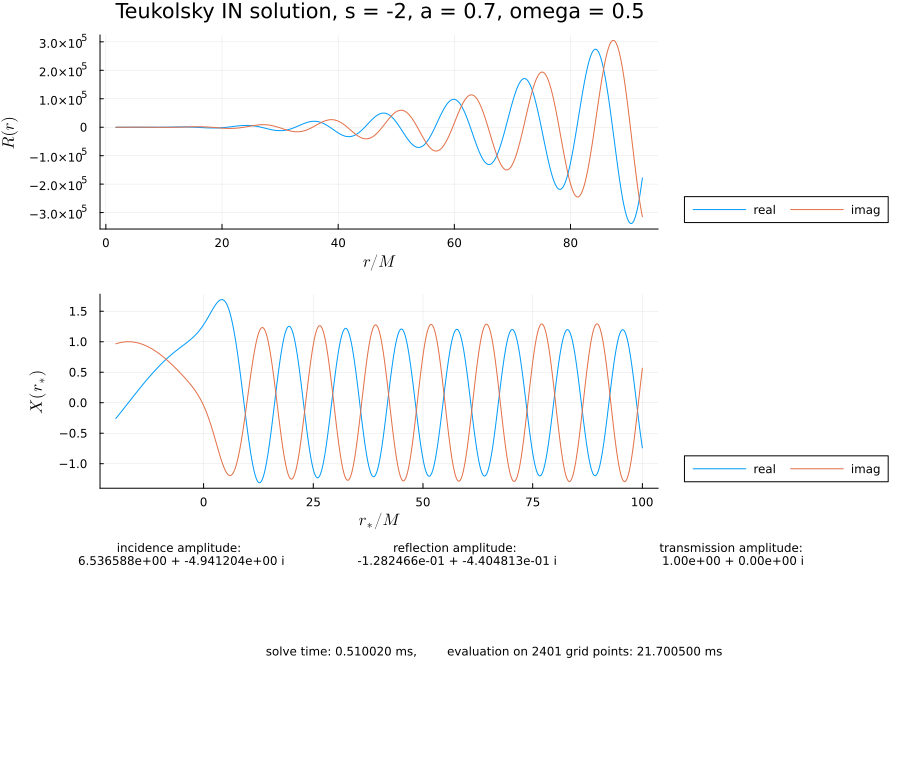

In [15]:
radial_demo_frame()